In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os

pd.set_option('display.max_columns', None)

In [2]:
mzn = gpd.read_file(os.path.join("..", "datos", "02_finales", "manzanas_censo_pct_zecditvallejo.geojson"))
print(mzn.shape)
mzn.head(1)

(6857, 73)


,CVEGEO,pob_total,pob_fem,pob_masc,pob_0_14,pob_15_17,pob_18_24,pob_25_29,pob_30_49,pob_50_59,pob_60_mas,pob_alfabeta,pob_analfabeta,pob_sin_escolaridad,pob_basica_comp,pob_posbasica,pob_media_sup,pob_superior,pea,pob_ocupada,pob_ocup_sup,pob_desocupada,pob_no_pea,viv_habitadas,viv_part_hab,ocup_viv,viv_deshabitadas,viv_elect,viv_agua,viv_drenaje,viv_serv_comp,viv_comp,viv_cel,viv_internet,viv_sin_comp_int,viv_1dorm,viv_hacinada,ratio_sexo,pct_0_14,pct_15_17,pct_18_24,pct_25_29,pct_30_49,pct_50_59,pct_60_mas,pct_alfabeta,pct_analfabeta,pct_sin_escolaridad,pct_basica_comp,pct_posbasica,pct_media_sup,pct_superior,pct_pea,pct_no_pea,pct_ocupada,pct_desocupada,pct_ocup_sup,pct_viv_elect,pct_viv_agua,pct_viv_drenaje,pct_viv_serv_comp,pct_viv_comp,pct_viv_cel,pct_viv_internet,pct_viv_sin_comp_int,pct_viv_1dorm,pct_viv_hacinada,pct_viv_deshabitadas,area_m2,den_pob_m2,den_pob_ha,entorno,geometry
0,1505700011489032,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3671.828904,0.0,0.0,Intermunicipal,"MULTIPOLYGON (((-99.22286 19.46978, -99.22384 ..."


<Axes: >

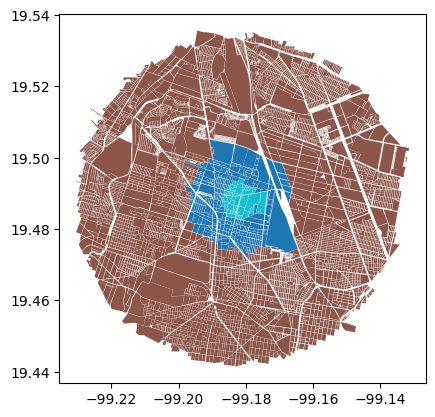

In [4]:
mzn.plot(column='entorno')

In [5]:
# Reproyectar a CRS métrico para operaciones espaciales de contenimiento
mzn_proj = mzn.to_crs("EPSG:6372")

print(f"Manzanas originales: {len(mzn):,}")
print(f"CRS original:        {mzn.crs}")
print(f"CRS proyectado:      {mzn_proj.crs}")
print(f"Tipos de geometría:  {mzn_proj.geom_type.value_counts().to_dict()}")

Manzanas originales: 6,857
CRS original:        EPSG:4326
CRS proyectado:      EPSG:6372
Tipos de geometría:  {'MultiPolygon': 6857}


In [6]:
# Detectar pares contenedor → contenida mediante sjoin espacial
pares = gpd.sjoin(
    mzn_proj[['CVEGEO', 'geometry']],
    mzn_proj[['CVEGEO', 'geometry']],
    how='inner',
    predicate='contains'
)

# Eliminar auto-joins (manzana "contenida" en sí misma)
pares = pares[pares['CVEGEO_left'] != pares['CVEGEO_right']].copy()
pares = pares[['CVEGEO_left', 'CVEGEO_right']].reset_index(drop=True)

print(f"Pares contenedor → contenida: {len(pares)}")
print(f"Manzanas contenedoras únicas: {pares['CVEGEO_left'].nunique()}")
print(f"Manzanas contenidas únicas:   {pares['CVEGEO_right'].nunique()}")

# Verificar si alguna manzana tiene más de una contenedora (posible error topológico)
multi = pares.groupby('CVEGEO_right')['CVEGEO_left'].nunique()
multi = multi[multi > 1]
if len(multi) > 0:
    print(f"\nADVERTENCIA: {len(multi)} manzanas tienen más de una contenedora:")
    print(multi)
else:
    print("\nOK: cada manzana contenida tiene exactamente una contenedora.")

pares.head(10)

Pares contenedor → contenida: 1685
Manzanas contenedoras únicas: 171
Manzanas contenidas únicas:   1685

OK: cada manzana contenida tiene exactamente una contenedora.


,CVEGEO_left,CVEGEO_right
0,0900200010909040,0900200010909036
1,0900200010909040,0900200010909031
2,0900200010909040,0900200010909030
3,0900200010909040,0900200010909032
4,0900200010909040,0900200010909029
5,0900200010909040,0900200010909017
6,0900200010909040,0900200010909033
7,0900200010909040,0900200010909018
8,0900200010909040,0900200010909019
9,0900200010909040,0900200010909035


Manzanas a eliminar (contenidas): 1685
Manzanas en resultado final:      5,172

OK: ninguna contenedora raíz está en la lista de contenidas.


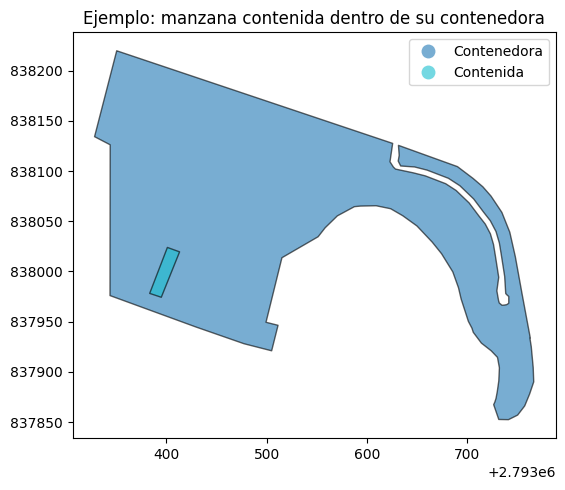

In [7]:
# Resolver cadenas de contenimiento (A contiene B, B contiene C → C se agrega a A)
def resolver_cadenas(pares_df):
    grafo = {}  # contenida → contenedora directa
    for _, row in pares_df.iterrows():
        if row['CVEGEO_right'] not in grafo:
            grafo[row['CVEGEO_right']] = row['CVEGEO_left']

    def encontrar_raiz(cvegeo, visitados=None):
        if visitados is None:
            visitados = set()
        if cvegeo in visitados:
            raise ValueError(f"Ciclo detectado: {cvegeo}")
        if cvegeo not in grafo:
            return cvegeo
        visitados.add(cvegeo)
        return encontrar_raiz(grafo[cvegeo], visitados)

    mapa = {contenida: encontrar_raiz(contenida) for contenida in grafo}
    return mapa, set(mapa.keys())

mapa_contencion, contenidas = resolver_cadenas(pares)

print(f"Manzanas a eliminar (contenidas): {len(contenidas)}")
print(f"Manzanas en resultado final:      {len(mzn) - len(contenidas):,}")

# Verificar que ninguna contenedora raíz esté también marcada como contenida
conflictos = set(mapa_contencion.values()) & contenidas
if conflictos:
    print(f"\nADVERTENCIA: {len(conflictos)} manzanas son raíz Y contenida. Revisar cadenas.")
else:
    print("\nOK: ninguna contenedora raíz está en la lista de contenidas.")

# Visualizar un caso de ejemplo
if len(contenidas) > 0:
    import matplotlib.pyplot as plt
    ejemplo_contenida   = list(contenidas)[0]
    ejemplo_contenedora = mapa_contencion[ejemplo_contenida]
    muestra = mzn_proj[mzn_proj['CVEGEO'].isin([ejemplo_contenida, ejemplo_contenedora])].copy()
    muestra['tipo'] = muestra['CVEGEO'].map({
        ejemplo_contenedora: 'Contenedora',
        ejemplo_contenida:   'Contenida'
    })
    ax = muestra.plot(column='tipo', legend=True, figsize=(6, 5), alpha=0.6, edgecolor='black')
    ax.set_title("Ejemplo: manzana contenida dentro de su contenedora")
    plt.tight_layout()
    plt.show()

In [8]:
# Columnas de conteo crudo a sumar (excluye pct_*, area_m2, den_*, entorno, geometry)
COLS_CONTEO = [
    'pob_total', 'pob_fem', 'pob_masc',
    'pob_0_14', 'pob_15_17', 'pob_18_24', 'pob_25_29', 'pob_30_49', 'pob_50_59', 'pob_60_mas',
    'pob_alfabeta', 'pob_analfabeta', 'pob_sin_escolaridad', 'pob_basica_comp',
    'pob_posbasica', 'pob_media_sup', 'pob_superior',
    'pea', 'pob_ocupada', 'pob_desocupada', 'pob_ocup_sup', 'pob_no_pea',
    'viv_habitadas', 'viv_part_hab', 'ocup_viv', 'viv_deshabitadas',
    'viv_elect', 'viv_agua', 'viv_drenaje', 'viv_serv_comp',
    'viv_comp', 'viv_cel', 'viv_internet', 'viv_sin_comp_int',
    'viv_1dorm', 'viv_hacinada'
]

faltantes = [c for c in COLS_CONTEO if c not in mzn.columns]
print(f"Columnas de conteo: {len(COLS_CONTEO)}  |  No encontradas: {faltantes if faltantes else 'ninguna'}")

# Agregar el mapa de contenimiento al dataframe
mzn_trabajo = mzn.copy()
mzn_trabajo['_contenedora_raiz'] = mzn_trabajo['CVEGEO'].map(mapa_contencion)

mask_contenidas = mzn_trabajo['_contenedora_raiz'].notna()
df_contenidas   = mzn_trabajo[mask_contenidas].copy()
df_normales     = mzn_trabajo[~mask_contenidas].copy()

print(f"\nManzanas normales (incluye contenedoras): {len(df_normales):,}")
print(f"Manzanas contenidas (a disolver):         {len(df_contenidas):,}")

# Calcular delta: suma de conteos de las contenidas agrupadas por contenedora raíz
# min_count=1: preserva NaN solo si TODOS los valores del grupo son NaN
delta = (
    df_contenidas
    .groupby('_contenedora_raiz')[COLS_CONTEO]
    .sum(min_count=1)
    .reset_index()
    .rename(columns={'_contenedora_raiz': 'CVEGEO'})
)

# .map({}) vacío produce dtype float64; forzar a str para compatibilidad con el merge posterior
delta['CVEGEO'] = delta['CVEGEO'].astype(str)

print(f"\nContenedoras que recibirán incremento: {len(delta):,}")
delta.head(3)

Columnas de conteo: 36  |  No encontradas: ninguna

Manzanas normales (incluye contenedoras): 5,172
Manzanas contenidas (a disolver):         1,685

Contenedoras que recibirán incremento: 171


,CVEGEO,pob_total,pob_fem,pob_masc,pob_0_14,pob_15_17,pob_18_24,pob_25_29,pob_30_49,pob_50_59,pob_60_mas,pob_alfabeta,pob_analfabeta,pob_sin_escolaridad,pob_basica_comp,pob_posbasica,pob_media_sup,pob_superior,pea,pob_ocupada,pob_desocupada,pob_ocup_sup,pob_no_pea,viv_habitadas,viv_part_hab,ocup_viv,viv_deshabitadas,viv_elect,viv_agua,viv_drenaje,viv_serv_comp,viv_comp,viv_cel,viv_internet,viv_sin_comp_int,viv_1dorm,viv_hacinada
0,0900200010025048,660.0,338.0,322.0,118.0,22.0,62.0,48.0,199.0,64.0,145.0,530.0,7.0,11.0,113.0,291.0,146.0,106.0,330.0,329.0,0.0,99.0,236.0,203.0,202.0,660.0,9.0,203.0,203.0,203.0,203.0,88.0,175.0,87.0,73.0,40.0,22.0
1,0900200010025049,1217.0,622.0,595.0,176.0,46.0,114.0,91.0,349.0,172.0,264.0,1020.0,0.0,0.0,217.0,606.0,174.0,325.0,660.0,655.0,0.0,313.0,414.0,389.0,384.0,1217.0,17.0,389.0,389.0,389.0,389.0,239.0,326.0,274.0,74.0,32.0,39.0
2,0900200010025050,132.0,73.0,59.0,17.0,7.0,11.0,10.0,44.0,11.0,30.0,110.0,3.0,3.0,22.0,61.0,36.0,17.0,64.0,59.0,4.0,14.0,56.0,45.0,45.0,132.0,0.0,45.0,45.0,45.0,45.0,14.0,37.0,32.0,10.0,0.0,8.0


In [9]:
# Separar contenedoras del resto de manzanas normales
mask_es_contenedora = df_normales['CVEGEO'].isin(delta['CVEGEO'])
df_contenedoras = df_normales[mask_es_contenedora].copy()
df_resto        = df_normales[~mask_es_contenedora].copy()

print(f"Contenedoras a actualizar: {len(df_contenedoras):,}")
print(f"Manzanas sin cambio:       {len(df_resto):,}")

# Merge y suma de los deltas sobre las contenedoras
df_contenedoras = df_contenedoras.merge(delta, on='CVEGEO', how='left', suffixes=('_orig', '_delta'))

for col in COLS_CONTEO:
    # add con fill_value=0: si uno es NaN se trata como 0 para la suma
    df_contenedoras[col] = df_contenedoras[f'{col}_orig'].add(
        df_contenedoras[f'{col}_delta'], fill_value=0
    )
    df_contenedoras.drop(columns=[f'{col}_orig', f'{col}_delta'], inplace=True)

print("Conteos actualizados en contenedoras.")

# Reconstruir GeoDataFrame: conservar solo columnas base (pct_* y den_* se recalcularán)
cols_base = ['CVEGEO', 'geometry', 'entorno'] + COLS_CONTEO

mzn_fusionado = pd.concat(
    [df_contenedoras[cols_base], df_resto[cols_base]],
    ignore_index=True
)
mzn_fusionado = gpd.GeoDataFrame(mzn_fusionado, geometry='geometry', crs=mzn.crs)

assert len(mzn_fusionado) == len(mzn) - len(contenidas), "Error: conteo de manzanas fusionadas incorrecto"
print(f"\nManzanas originales: {len(mzn):,}  →  Manzanas fusionadas: {len(mzn_fusionado):,}")
print("Verificación de conteo: OK")

Contenedoras a actualizar: 171
Manzanas sin cambio:       5,001
Conteos actualizados en contenedoras.

Manzanas originales: 6,857  →  Manzanas fusionadas: 5,172
Verificación de conteo: OK


In [10]:
# Recalcular area_m2, densidades y columnas pct_* / ratio_sexo
mzn_fusionado_proj = mzn_fusionado.to_crs("EPSG:6372")
mzn_fusionado['area_m2']    = mzn_fusionado_proj.geometry.area
mzn_fusionado['den_pob_m2'] = mzn_fusionado['pob_total'] / mzn_fusionado['area_m2']
mzn_fusionado['den_pob_ha'] = mzn_fusionado['pob_total'] / (mzn_fusionado['area_m2'] / 10_000)

def agregar_porcentajes(gdf):
    df = gdf.copy()

    def pct(num, den):
        return (num / den.replace(0, float('nan')) * 100).round(2)

    # Ratio de sexos (hombres/mujeres × 100)
    df['ratio_sexo'] = (df['pob_masc'] / df['pob_fem'].replace(0, float('nan')) * 100).round(2)

    # Grupos de edad (denominador: pob_total)
    for col in ['pob_0_14', 'pob_15_17',
                'pob_18_24', 'pob_25_29', 'pob_30_49', 'pob_50_59', 'pob_60_mas']:
        df[f'pct_{col.removeprefix("pob_")}'] = pct(df[col], df['pob_total'])

    # Educación (denominador: pob 15+ años)
    den_15_mas = df['pob_total'] - df['pob_0_14']
    for col in ['pob_alfabeta', 'pob_analfabeta', 'pob_sin_escolaridad',
                'pob_basica_comp', 'pob_posbasica', 'pob_media_sup', 'pob_superior']:
        df[f'pct_{col.removeprefix("pob_")}'] = pct(df[col], den_15_mas)

    # Actividad económica
    df['pct_pea']        = pct(df['pea'],            den_15_mas)
    df['pct_no_pea']     = pct(df['pob_no_pea'],     den_15_mas)
    df['pct_ocupada']    = pct(df['pob_ocupada'],    df['pea'])
    df['pct_desocupada'] = pct(df['pob_desocupada'], df['pea'])
    df['pct_ocup_sup']   = pct(df['pob_ocup_sup'],   df['pob_ocupada'])

    # Vivienda (denominador: viv_part_hab)
    for col in ['viv_elect', 'viv_agua', 'viv_drenaje', 'viv_serv_comp',
                'viv_comp', 'viv_cel', 'viv_internet', 'viv_sin_comp_int',
                'viv_1dorm', 'viv_hacinada']:
        df[f'pct_{col}'] = pct(df[col], df['viv_part_hab'])

    df['pct_viv_deshabitadas'] = pct(
        df['viv_deshabitadas'],
        df['viv_habitadas'] + df['viv_deshabitadas']
    )
    return df

mzn_final = agregar_porcentajes(mzn_fusionado)

cols_der = [c for c in mzn_final.columns if c.startswith('pct_') or c == 'ratio_sexo']
print(f"Columnas derivadas recalculadas: {len(cols_der)}")
print(f"Shape final: {mzn_final.shape}")
mzn_final[['ratio_sexo'] + cols_der[:4]].describe().T[['mean', 'min', 'max']].round(2)

Columnas derivadas recalculadas: 31
Shape final: (5172, 73)


,mean,min,max
ratio_sexo,91.12,0.0,600.00
ratio_sexo,91.12,0.0,600.00
pct_0_14,14.11,0.0,50.00
pct_15_17,2.86,0.0,20.00
pct_18_24,9.05,0.0,42.86


In [11]:
# Verificación: población total debe conservarse (diferencia mínima por NaN tratados como 0)
pob_orig = mzn['pob_total'].sum()
pob_final = mzn_final['pob_total'].sum()
print(f"Población original:  {pob_orig:,.0f}")
print(f"Población final:     {pob_final:,.0f}")
print(f"Diferencia:          {pob_final - pob_orig:,.0f}  (debe ser 0 o cercano)")

# Verificación espacial: no deben quedar manzanas contenidas en otras
pares_check = gpd.sjoin(
    mzn_final.to_crs("EPSG:6372")[['CVEGEO', 'geometry']],
    mzn_final.to_crs("EPSG:6372")[['CVEGEO', 'geometry']],
    how='inner', predicate='contains'
)
pares_check = pares_check[pares_check['CVEGEO_left'] != pares_check['CVEGEO_right']]

if len(pares_check) == 0:
    print("\nVerificación espacial: OK — no quedan manzanas contenidas.")
else:
    print(f"\nADVERTENCIA: aún quedan {len(pares_check)} pares de contenimiento sin resolver.")
    print(pares_check[['CVEGEO_left', 'CVEGEO_right']])

Población original:  943,479
Población final:     943,479
Diferencia:          0  (debe ser 0 o cercano)

Verificación espacial: OK — no quedan manzanas contenidas.


In [12]:
mzn_final.head(1)

,CVEGEO,geometry,entorno,pob_total,pob_fem,pob_masc,pob_0_14,pob_15_17,pob_18_24,pob_25_29,pob_30_49,pob_50_59,pob_60_mas,pob_alfabeta,pob_analfabeta,pob_sin_escolaridad,pob_basica_comp,pob_posbasica,pob_media_sup,pob_superior,pea,pob_ocupada,pob_desocupada,pob_ocup_sup,pob_no_pea,viv_habitadas,viv_part_hab,ocup_viv,viv_deshabitadas,viv_elect,viv_agua,viv_drenaje,viv_serv_comp,viv_comp,viv_cel,viv_internet,viv_sin_comp_int,viv_1dorm,viv_hacinada,area_m2,den_pob_m2,den_pob_ha,ratio_sexo,pct_0_14,pct_15_17,pct_18_24,pct_25_29,pct_30_49,pct_50_59,pct_60_mas,pct_alfabeta,pct_analfabeta,pct_sin_escolaridad,pct_basica_comp,pct_posbasica,pct_media_sup,pct_superior,pct_pea,pct_no_pea,pct_ocupada,pct_desocupada,pct_ocup_sup,pct_viv_elect,pct_viv_agua,pct_viv_drenaje,pct_viv_serv_comp,pct_viv_comp,pct_viv_cel,pct_viv_internet,pct_viv_sin_comp_int,pct_viv_1dorm,pct_viv_hacinada,pct_viv_deshabitadas
0,0900200010909040,"MULTIPOLYGON (((-99.16981 19.47286, -99.1707 1...",Intermunicipal,1810.0,969.0,837.0,242.0,37.0,138.0,127.0,525.0,233.0,463.0,1555.0,0.0,0.0,125.0,1259.0,398.0,730.0,936.0,917.0,7.0,565.0,669.0,645.0,637.0,1806.0,49.0,644.0,644.0,644.0,644.0,446.0,588.0,528.0,82.0,37.0,21.0,46058.90826,0.039298,392.975011,86.38,13.37,2.04,7.62,7.02,29.01,12.87,25.58,99.17,0.0,0.0,7.97,80.29,25.38,46.56,59.69,42.67,97.97,0.75,61.61,101.1,101.1,101.1,101.1,70.02,92.31,82.89,12.87,5.81,3.3,7.06


In [13]:
import os

nombre = 'manzanas_censo_pct_zecditvallejo_entorno.geojson'
rutas  = [
    os.path.join('..', 'datos', '02_finales', nombre),
    os.path.join('..', 'docs', 'datos', nombre),
]

mzn_export = mzn_final.to_crs("EPSG:4326")
for ruta in rutas:
    mzn_export.to_file(ruta, driver='GeoJSON')
    print(f"Exportado → {ruta}")

print(f"\nRegistros: {len(mzn_export):,}  |  Columnas: {mzn_export.shape[1]}")

Exportado → ..\datos\02_finales\manzanas_censo_pct_zecditvallejo_entorno.geojson
Exportado → ..\docs\datos\manzanas_censo_pct_zecditvallejo_entorno.geojson

Registros: 5,172  |  Columnas: 73


<Axes: >

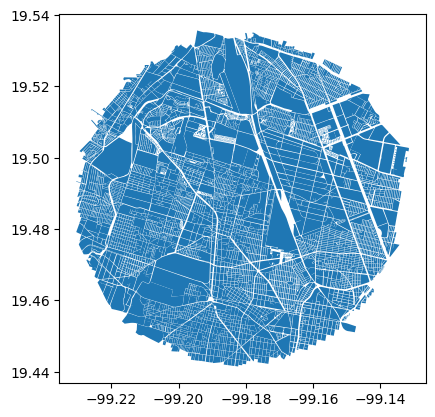

In [14]:
mzn_final.plot()